In [1]:
%matplotlib inline
%gui qt6

import mne
import matplotlib.pyplot as plt
import numpy as np


Number of channels used in analysis: 12
Number of unselected channels: 20
Total number of channels: 32


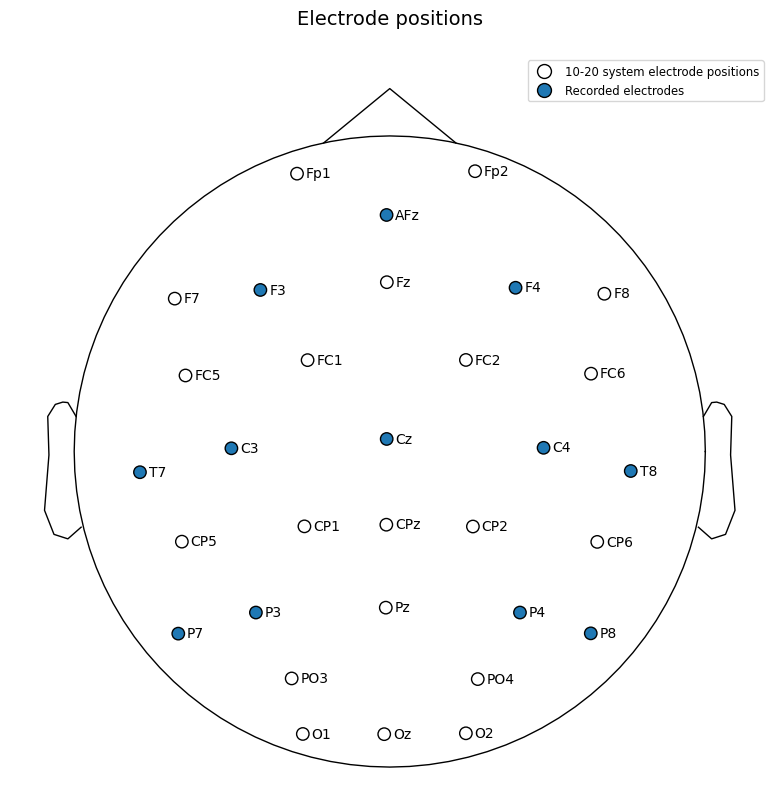

In [66]:
layout: mne.channels.DigMontage = mne.channels.make_standard_montage("standard_1020")

# channels used in analysis
selected_channels = [
    "C3",
    "C4",
    "Cz",
    "F3",
    "F4",
    "P3",
    "P4",
    "P7",
    "P8",
    "T7",
    "T8",
    "AFz",
]
standard_32_unselected = [
    "Fp1",
    "Fp2",
    "F7",
    "Fz",
    "F8",
    "FC5",
    "FC1",
    "FC2",
    "FC6",
    "CP5",
    "CP1",
    "CPz",
    "CP2",
    "CP6",
    "Pz",
    "PO3",
    "PO4",
    "O1",
    "Oz",
    "O2",
]

print("Number of channels used in analysis:", len(selected_channels))
print("Number of unselected channels:", len(standard_32_unselected))
print("Total number of channels:", len(selected_channels) + len(standard_32_unselected))
# plot the layout with 32 electrodes, highlighting the channels used in analysis
info: mne.Info = mne.create_info(
    selected_channels + standard_32_unselected, sfreq=250.0, ch_types="eeg"
)
info.set_montage(layout)


ch_names = info.ch_names
group_indices = [
    [ch_names.index(ch) for ch in standard_32_unselected],
    [ch_names.index(ch) for ch in selected_channels],
]

cmap = plt.cm.colors.ListedColormap(["white", plt.cm.Paired(1)])

fig = mne.viz.plot_sensors(
    info,
    show_names=True,
    ch_type="eeg",
    show=False,
    block=True,
    ch_groups=group_indices,
    cmap=cmap,
    pointsize=80,
    linewidth=1,
    sphere=(0, 0.022, 0, 0.09),
)

fig.set_size_inches(8, 8)

# add legend
legend_elements = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle=None,
        color="black",
        label="10-20 system electrode positions",
        linewidth=0,
        markerfacecolor="white",
        markersize=10,
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linewidth=0,
        label="Recorded electrodes",
        markerfacecolor=cmap(1),
        markersize=10,
    ),
]
plt.legend(handles=legend_elements, loc="upper right", fontsize="small")
# add title
plt.title("Electrode positions\n", fontsize=14)
# add space below title
# plt.suptitle("Electrode placement for a 32-channel Standard 10-20 system)")

fig.savefig("../out/electrode_placement.png", dpi=300)


## Effect of EOG regression on the EEG signal

Reproduces the bandpass filter + average reference + `mne.preprocessing.EOGRegression` step
applied in `src/preprocess-data.py`, then plots a window containing eye blinks and saccades to
illustrate how ocular artifact bleed-through is removed from the scalp channels.

In [59]:
import os
import sys
from pathlib import Path

sys.path.insert(0, "../src")
from data import eeg

# Representative recording
subject_id = 1
stimulus: eeg.StimulusName = "StoryCorps_Q&A"

data_dir = Path(os.environ["EEG_DATA_PATH"])

# Reproduce preprocessing up through EOG regression (see src/preprocess-data.py)
raw = eeg.load_eeg(data_dir, subject_id, stimulus)
raw.load_data()
raw.filter(l_freq=0.5, h_freq=40.0, method="fir", picks="all", verbose="error")
raw.pick(["eeg", "eog"], verbose="error")
raw.set_eeg_reference("average", projection=False, verbose="error")

raw_before = raw.copy()
weights = mne.preprocessing.EOGRegression().fit(raw_before)
raw_after = weights.apply(raw_before.copy())

# Pick a window containing a few blinks (use EOG to locate them)
sfreq = raw_before.info["sfreq"]
eog_events = mne.preprocessing.find_eog_events(
    raw_before, ch_name="VA_EOG", verbose="error"
)

window_seconds = 5.0
# find densest area
eog_event_counts = np.bincount((eog_events[:, 0] // sfreq * window_seconds).astype(int))

event_idx = np.argmax(eog_event_counts)

# robustly locate densest 5s window and pick a center sample
bin_size = int(sfreq * window_seconds)
bin_idx = (eog_events[:, 0] // bin_size).astype(int)
eog_event_counts = np.bincount(bin_idx)
event_bin = int(np.argmax(eog_event_counts))
in_bin = np.where(bin_idx == event_bin)[0]
if in_bin.size:
    center_sample = int(np.median(eog_events[in_bin, 0]))
else:
    center_sample = int(event_bin * bin_size + bin_size // 2)

tmin = max(0.0, (center_sample - int(2 * sfreq)) / sfreq)
tmax = min(raw_before.times[-1], tmin + window_seconds)

frontal_channels = ["F3", "F4"]  # highly affected by ocular artifacts
posterior_channels = [
    "C3",
    "C4",
]  # less affected by ocular artifacts (control channels)
display_channels = frontal_channels + posterior_channels
eog_channels = [
    "HL_EOG",
    "HR_EOG",
    "VA_EOG",
    "VB_EOG",
]

data_eog = raw_before.get_data(picks=eog_channels, tmin=tmin, tmax=tmax)
data_before = raw_before.get_data(picks=display_channels, tmin=tmin, tmax=tmax)
data_after = raw_after.get_data(picks=display_channels, tmin=tmin, tmax=tmax)
t = np.arange(data_before.shape[1]) / sfreq


No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


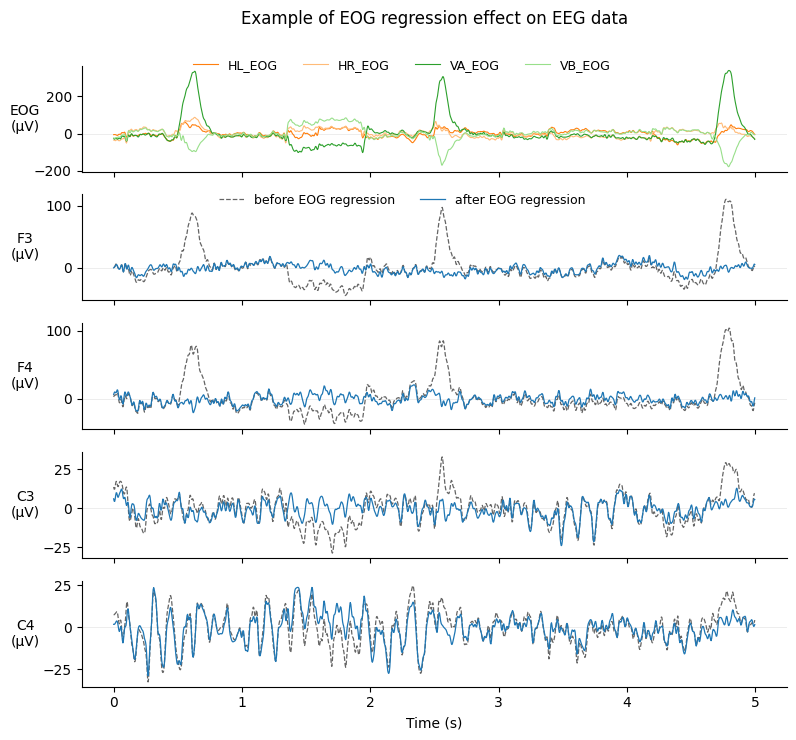

In [68]:
uv = 1e6
before_color = "#232323"
after_color = "#1f77b4"
eog_colors = ["#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a"]
y_label_offset = -0.08
n_rows = len(display_channels) + 1
fig, axes = plt.subplots(n_rows, 1, figsize=(8, 1.5 * n_rows), sharex=True)
ax = axes[0]
for i, ch in enumerate(eog_channels):
    ax.plot(t, data_eog[i] * uv, color=eog_colors[i], linewidth=0.8, label=ch)
    handles, labels = ax.get_legend_handles_labels()
ax.set_ylabel("EOG\n(µV)", rotation=0, ha="center", va="center")
ax.yaxis.set_label_coords(y_label_offset, 0.5)
ax.axhline(0, color="0.9", linewidth=0.5, zorder=0)
fig.legend(
    handles,
    labels,
    loc="upper center",
    fontsize=9,
    frameon=False,
    ncol=len(eog_channels),
    bbox_to_anchor=(0.5, 0.93),
)


for j, ch in enumerate(display_channels):
    ax = axes[1 + j]
    ax.plot(
        t,
        data_before[j] * uv,
        color=before_color,
        alpha=0.7,
        linestyle="--",
        linewidth=0.9,
        label="before EOG regression",
    )
    ax.plot(
        t,
        data_after[j] * uv,
        color=after_color,
        linewidth=0.9,
        label="after EOG regression",
    )
    label = f"{ch}\n(µV)"
    # if ch in posterior_channels:
    #     label += "\n(control)"
    ax.set_ylabel(label, rotation=0, ha="center", va="center")
    ax.yaxis.set_label_coords(y_label_offset, 0.5)
    ax.axhline(0, color="0.9", linewidth=0.5, zorder=0)
    handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    fontsize=9,
    frameon=False,
    ncol=2,
    bbox_to_anchor=(0.5, 0.75),
)
axes[-1].set_xlabel("Time (s)")
axes[0].set_title(
    "Example of EOG regression effect on EEG data",
    pad=30,
)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig.tight_layout()
fig.savefig("../out/eog_regression_effect.png", dpi=300, bbox_inches="tight")
plt.show()
